In [1]:
!pip install -q --upgrade pip
!pip install -q numpy pandas matplotlib seaborn scikit-learn optuna xgboost catboost torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.4 MB/s eta 0:00:0000:0100:01


# OULAD Modeling - XGBoost + CatBoost + Tabular DL + Stacking

Notebook huan luyen 3 base models co Optuna tuning:
- XGBoost
- CatBoost
- Tabular Deep Learning (PyTorch MLP)

Sau do xay dung Stacking Ensemble (OOF) de tranh data leakage.

In [2]:
import os
import json
import time
import copy
import random
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print('Imports OK')

Imports OK


In [3]:
# =========================
# Config
# =========================
RANDOM_SEED = 42
OPTUNA_TRIALS = 50
N_FOLDS = 5
VAL_SIZE = 0.2
NUM_CLASSES = 4

LABEL_MAP = {0: 'Pass', 1: 'Fail', 2: 'Withdrawn', 3: 'Distinction'}

DATA_PATH = '/kaggle/input/datasets/thinhuit/oulad-dataset-v5-2'

SAVE_DIR = './saved_models_xgb_cat_tabdl_stacking'
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print(f'DATA_PATH: {DATA_PATH}')
print(f'DEVICE: {DEVICE}')
print(f'OPTUNA_TRIALS: {OPTUNA_TRIALS}')

DATA_PATH: /kaggle/input/datasets/thinhuit/oulad-dataset-v5-2
DEVICE: cuda
OPTUNA_TRIALS: 50


In [4]:
# =========================
# Load data
# =========================
start_time = time.time()

df_train_scaled = pd.read_csv(os.path.join(DATA_PATH, 'df_train_scaled.csv'))
df_test_scaled = pd.read_csv(os.path.join(DATA_PATH, 'df_test_scaled.csv'))

feature_json = os.path.join(DATA_PATH, 'feature_cols.json')
if os.path.exists(feature_json):
    with open(feature_json, 'r') as f:
        feature_cols = json.load(f)
    feature_cols = [c for c in feature_cols if c != 'target']
else:
    exclude = {'target'}
    feature_cols = [c for c in df_train_scaled.columns if c not in exclude]

X_train = df_train_scaled[feature_cols].values.astype(np.float32)
y_train = df_train_scaled['target'].values.astype(int)
X_test = df_test_scaled[feature_cols].values.astype(np.float32)
y_test = df_test_scaled['target'].values.astype(int)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_train
)

print(f'Train shape: {X_train.shape} | Test shape: {X_test.shape}')
print(f'Num features: {len(feature_cols)}')
print(f'Data loaded in {time.time()-start_time:.2f}s')

Train shape: (26063, 64) | Test shape: (6530, 64)
Num features: 64
Data loaded in 0.91s


In [5]:
def evaluate_model(name, y_true, y_pred, show_plot=True):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')

    print('\n' + '=' * 60)
    print(name)
    print('=' * 60)
    print(f'Accuracy:    {acc:.4f}')
    print(f'Macro-F1:    {f1_macro:.4f}  << PRIMARY')
    print(f'Weighted-F1: {f1_weighted:.4f}')
    print(classification_report(y_true, y_pred, target_names=[LABEL_MAP[i] for i in range(NUM_CLASSES)]))

    if show_plot:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=[LABEL_MAP[i] for i in range(NUM_CLASSES)],
                    yticklabels=[LABEL_MAP[i] for i in range(NUM_CLASSES)])
        plt.title(f'CM: {name}')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()

    return {
        'name': name,
        'accuracy': acc,
        'macro_f1': f1_macro,
        'weighted_f1': f1_weighted
    }

In [6]:
# =========================
# Tabular DL helper
# =========================
class TabularMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, num_classes):
        super().__init__()
        layers = []
        in_dim = input_dim
        for _ in range(num_layers):
            layers.extend([
                nn.Linear(in_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout),
            ])
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def _make_loader(X, y, batch_size, shuffle):
    x_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(x_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)


def train_tabdl_once(X_tr_, y_tr_, X_va_, y_va_, params, device=DEVICE):
    model = TabularMLP(
        input_dim=X_tr_.shape[1],
        hidden_dim=params['hidden_dim'],
        num_layers=params['num_layers'],
        dropout=params['dropout'],
        num_classes=NUM_CLASSES
    ).to(device)

    train_loader = _make_loader(X_tr_, y_tr_, params['batch_size'], shuffle=True)
    val_loader = _make_loader(X_va_, y_va_, params['batch_size'], shuffle=False)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])

    best_state = None
    best_f1 = -1
    patience = params['patience']
    bad_epochs = 0

    for _ in range(params['epochs']):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        preds = []
        trues = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                logits = model(xb)
                pred = torch.argmax(logits, dim=1).cpu().numpy()
                preds.extend(pred.tolist())
                trues.extend(yb.numpy().tolist())

        f1_val = f1_score(trues, preds, average='macro')
        if f1_val > best_f1:
            best_f1 = f1_val
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, best_f1


def predict_proba_tabdl(model, X, batch_size=1024, device=DEVICE):
    model.eval()
    x_t = torch.tensor(X, dtype=torch.float32)
    loader = DataLoader(TensorDataset(x_t), batch_size=batch_size, shuffle=False)
    probs = []
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            logits = model(xb)
            p = torch.softmax(logits, dim=1).cpu().numpy()
            probs.append(p)
    return np.vstack(probs)


XGBOOST + OPTUNA
Best Val Macro-F1: 0.6581 (353.3s)

XGBoost
Accuracy:    0.7194
Macro-F1:    0.6410  << PRIMARY
Weighted-F1: 0.7041
              precision    recall  f1-score   support

        Pass       0.78      0.81      0.79      2043
        Fail       0.60      0.42      0.50      1410
   Withdrawn       0.74      0.90      0.81      2465
 Distinction       0.59      0.39      0.47       612

    accuracy                           0.72      6530
   macro avg       0.68      0.63      0.64      6530
weighted avg       0.71      0.72      0.70      6530



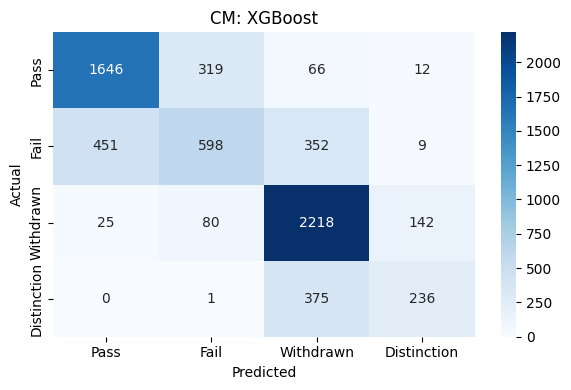

In [7]:
# =========================
# XGBoost + Optuna
# =========================
print('\n' + '='*60)
print('XGBOOST + OPTUNA')
print('='*60)

t0 = time.time()

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1200),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'objective': 'multi:softprob',
        'num_class': NUM_CLASSES,
        'eval_metric': 'mlogloss',
        'random_state': RANDOM_SEED,
        'verbosity': 0,
        'tree_method': 'hist',
    }

    if torch.cuda.is_available():
        params['device'] = 'cuda'

    model = XGBClassifier(**params)
    model.fit(X_tr, y_tr, verbose=False)
    pred = model.predict(X_val)
    return f1_score(y_val, pred, average='macro')

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=OPTUNA_TRIALS)
print(f'Best Val Macro-F1: {study_xgb.best_value:.4f} ({time.time()-t0:.1f}s)')

best_xgb_params = study_xgb.best_params
best_xgb_params.update({
    'objective': 'multi:softprob',
    'num_class': NUM_CLASSES,
    'eval_metric': 'mlogloss',
    'random_state': RANDOM_SEED,
    'verbosity': 0,
    'tree_method': 'hist',
})
if torch.cuda.is_available():
    best_xgb_params['device'] = 'cuda'

best_xgb = XGBClassifier(**best_xgb_params)
best_xgb.fit(X_train, y_train, verbose=False)
result_xgb = evaluate_model('XGBoost', y_test, best_xgb.predict(X_test))


CATBOOST + OPTUNA
Best Val Macro-F1: 0.6522 (620.3s)

CatBoost
Accuracy:    0.7161
Macro-F1:    0.6428  << PRIMARY
Weighted-F1: 0.7021
              precision    recall  f1-score   support

        Pass       0.77      0.79      0.78      2043
        Fail       0.58      0.43      0.49      1410
   Withdrawn       0.74      0.89      0.81      2465
 Distinction       0.62      0.40      0.49       612

    accuracy                           0.72      6530
   macro avg       0.68      0.63      0.64      6530
weighted avg       0.70      0.72      0.70      6530



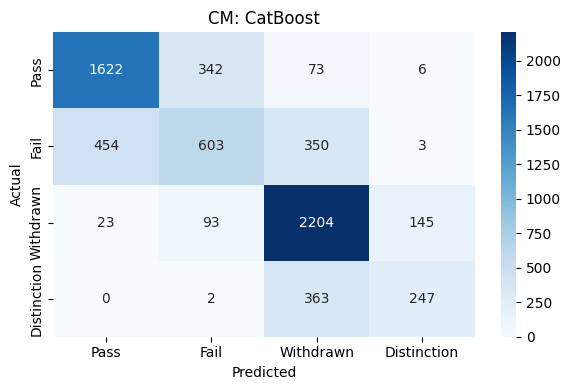

In [8]:
# =========================
# CatBoost + Optuna
# =========================
print('\n' + '='*60)
print('CATBOOST + OPTUNA')
print('='*60)

t0 = time.time()

def cat_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'loss_function': 'MultiClass',
        'random_seed': RANDOM_SEED,
        'verbose': 0,
    }

    if torch.cuda.is_available():
        params['task_type'] = 'GPU'

    model = CatBoostClassifier(**params)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val).astype(int).reshape(-1)
    return f1_score(y_val, pred, average='macro')

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(cat_objective, n_trials=OPTUNA_TRIALS)
print(f'Best Val Macro-F1: {study_cat.best_value:.4f} ({time.time()-t0:.1f}s)')

best_cat_params = study_cat.best_params
best_cat_params.update({
    'loss_function': 'MultiClass',
    'random_seed': RANDOM_SEED,
    'verbose': 0,
})
if torch.cuda.is_available():
    best_cat_params['task_type'] = 'GPU'

best_cat = CatBoostClassifier(**best_cat_params)
best_cat.fit(X_train, y_train)
result_cat = evaluate_model('CatBoost', y_test, best_cat.predict(X_test).astype(int).reshape(-1))


TABULAR DL (MLP) + OPTUNA
Best Val Macro-F1: 0.6545 (830.2s)

Tabular DL (MLP)
Accuracy:    0.7014
Macro-F1:    0.6541  << PRIMARY
Weighted-F1: 0.7007
              precision    recall  f1-score   support

        Pass       0.81      0.72      0.76      2043
        Fail       0.54      0.53      0.54      1410
   Withdrawn       0.75      0.82      0.78      2465
 Distinction       0.52      0.54      0.53       612

    accuracy                           0.70      6530
   macro avg       0.66      0.65      0.65      6530
weighted avg       0.70      0.70      0.70      6530



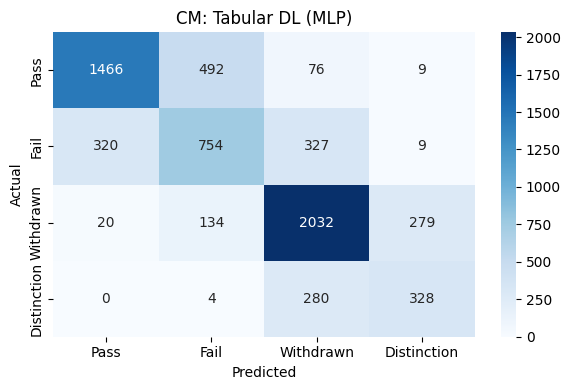

In [9]:
# =========================
# Tabular Deep Learning (PyTorch MLP) + Optuna
# =========================
print('\n' + '='*60)
print('TABULAR DL (MLP) + OPTUNA')
print('='*60)

t0 = time.time()

def tabdl_objective(trial):
    params = {
        'hidden_dim': trial.suggest_categorical('hidden_dim', [64, 128, 256, 512]),
        'num_layers': trial.suggest_int('num_layers', 1, 4),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'lr': trial.suggest_float('lr', 1e-4, 5e-3, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-7, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [64, 128, 256, 512]),
        'epochs': trial.suggest_int('epochs', 30, 120),
        'patience': 12,
    }
    _, best_f1 = train_tabdl_once(X_tr, y_tr, X_val, y_val, params, device=DEVICE)
    return best_f1

study_tabdl = optuna.create_study(direction='maximize')
study_tabdl.optimize(tabdl_objective, n_trials=OPTUNA_TRIALS)
print(f'Best Val Macro-F1: {study_tabdl.best_value:.4f} ({time.time()-t0:.1f}s)')

best_tabdl_params = study_tabdl.best_params.copy()
best_tabdl_params['patience'] = 15

# train final with a holdout from train for early stopping
X_full_tr, X_full_va, y_full_tr, y_full_va = train_test_split(
    X_train, y_train,
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_train
)
best_tabdl, _ = train_tabdl_once(X_full_tr, y_full_tr, X_full_va, y_full_va, best_tabdl_params, device=DEVICE)

tabdl_prob_test = predict_proba_tabdl(best_tabdl, X_test, batch_size=1024, device=DEVICE)
result_tabdl = evaluate_model('Tabular DL (MLP)', y_test, np.argmax(tabdl_prob_test, axis=1))

STACKING (OOF) - XGB + CAT + TABDL
Fold 1/5 | train=20850 val=5213
Fold 2/5 | train=20850 val=5213
Fold 3/5 | train=20850 val=5213
Fold 4/5 | train=20851 val=5212
Fold 5/5 | train=20851 val=5212

Stacking (OOF + LogisticRegression)
Accuracy:    0.7251
Macro-F1:    0.6532  << PRIMARY
Weighted-F1: 0.7114
              precision    recall  f1-score   support

        Pass       0.77      0.81      0.79      2043
        Fail       0.60      0.44      0.51      1410
   Withdrawn       0.75      0.89      0.81      2465
 Distinction       0.63      0.41      0.50       612

    accuracy                           0.73      6530
   macro avg       0.69      0.64      0.65      6530
weighted avg       0.71      0.73      0.71      6530



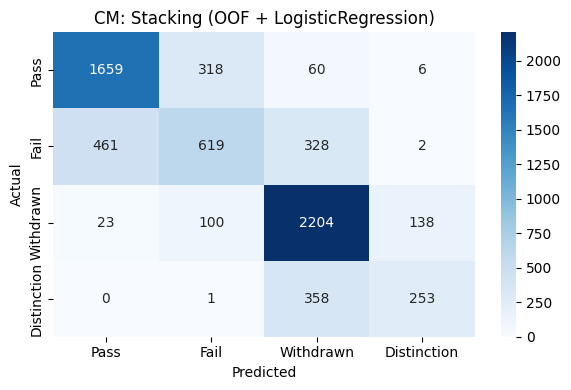

OOF stacking completed in 182.7s


In [10]:
# =========================
# Stacking Ensemble (OOF, anti-leakage)
# =========================
print('STACKING (OOF) - XGB + CAT + TABDL')

t0 = time.time()
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# OOF probs
n_train = len(y_train)
n_test = len(y_test)
oof_xgb = np.zeros((n_train, NUM_CLASSES), dtype=np.float32)
oof_cat = np.zeros((n_train, NUM_CLASSES), dtype=np.float32)
oof_tab = np.zeros((n_train, NUM_CLASSES), dtype=np.float32)

test_xgb = np.zeros((n_test, NUM_CLASSES), dtype=np.float32)
test_cat = np.zeros((n_test, NUM_CLASSES), dtype=np.float32)
test_tab = np.zeros((n_test, NUM_CLASSES), dtype=np.float32)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f'Fold {fold}/{N_FOLDS} | train={len(tr_idx)} val={len(va_idx)}')
    Xf_tr, yf_tr = X_train[tr_idx], y_train[tr_idx]
    Xf_va, yf_va = X_train[va_idx], y_train[va_idx]

    # XGBoost
    m_xgb = XGBClassifier(**best_xgb_params)
    m_xgb.fit(Xf_tr, yf_tr, verbose=False)
    oof_xgb[va_idx] = m_xgb.predict_proba(Xf_va)
    test_xgb += m_xgb.predict_proba(X_test) / N_FOLDS

    # CatBoost
    m_cat = CatBoostClassifier(**best_cat_params)
    m_cat.fit(Xf_tr, yf_tr)
    oof_cat[va_idx] = m_cat.predict_proba(Xf_va)
    test_cat += m_cat.predict_proba(X_test) / N_FOLDS

    # TabDL
    m_tab, _ = train_tabdl_once(Xf_tr, yf_tr, Xf_va, yf_va, best_tabdl_params, device=DEVICE)
    oof_tab[va_idx] = predict_proba_tabdl(m_tab, Xf_va, batch_size=1024, device=DEVICE)
    test_tab += predict_proba_tabdl(m_tab, X_test, batch_size=1024, device=DEVICE) / N_FOLDS

# meta feature: 3 models x 4 probs = 12 feature
meta_train = np.hstack([oof_xgb, oof_cat, oof_tab])
meta_test = np.hstack([test_xgb, test_cat, test_tab])

meta_learner = LogisticRegression(
    max_iter=2000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=RANDOM_SEED
)
meta_learner.fit(meta_train, y_train)

y_pred_stack = meta_learner.predict(meta_test)
result_stack = evaluate_model('Stacking (OOF + LogisticRegression)', y_test, y_pred_stack)
print(f'OOF stacking completed in {time.time() - t0:.1f}s')


Soft Voting (Equal: XGB+Cat+TabDL)
Accuracy:    0.7250
Macro-F1:    0.6540  << PRIMARY
Weighted-F1: 0.7118
              precision    recall  f1-score   support

        Pass       0.78      0.80      0.79      2043
        Fail       0.60      0.45      0.51      1410
   Withdrawn       0.74      0.90      0.81      2465
 Distinction       0.62      0.42      0.50       612

    accuracy                           0.72      6530
   macro avg       0.69      0.64      0.65      6530
weighted avg       0.71      0.72      0.71      6530



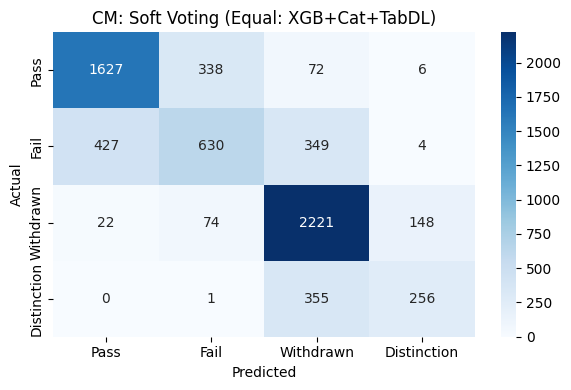


Ranking by Macro-F1:
                                  name  accuracy  macro_f1  weighted_f1
0                     Tabular DL (MLP)  0.701378  0.654089     0.700730
1   Soft Voting (Equal: XGB+Cat+TabDL)  0.724962  0.653984     0.711837
2  Stacking (OOF + LogisticRegression)  0.725115  0.653223     0.711383
3                             CatBoost  0.716080  0.642792     0.702062
4                              XGBoost  0.719449  0.641005     0.704083

Best model: Tabular DL (MLP) | Macro-F1=0.6541


In [11]:
# =========================
# Optional: soft voting baseline
# =========================
prob_soft = (test_xgb + test_cat + test_tab) / 3
y_pred_soft = np.argmax(prob_soft, axis=1)
result_soft = evaluate_model('Soft Voting (Equal: XGB+Cat+TabDL)', y_test, y_pred_soft)

results = [result_xgb, result_cat, result_tabdl, result_stack, result_soft]
results_df = pd.DataFrame(results).sort_values('macro_f1', ascending=False).reset_index(drop=True)
print('\nRanking by Macro-F1:')
print(results_df[['name', 'accuracy', 'macro_f1', 'weighted_f1']])

best_result = results_df.iloc[0].to_dict()
print(f"\nBest model: {best_result['name']} | Macro-F1={best_result['macro_f1']:.4f}")

In [12]:
# =========================
# Save models + metadata
# =========================
with open(os.path.join(SAVE_DIR, 'xgboost_best.pkl'), 'wb') as f:
    pickle.dump(best_xgb, f)
with open(os.path.join(SAVE_DIR, 'catboost_best.pkl'), 'wb') as f:
    pickle.dump(best_cat, f)

# torch model
torch.save(best_tabdl.state_dict(), os.path.join(SAVE_DIR, 'tabdl_best.pt'))
with open(os.path.join(SAVE_DIR, 'tabdl_arch.json'), 'w') as f:
    json.dump({
        'input_dim': int(X_train.shape[1]),
        'num_classes': NUM_CLASSES,
        **best_tabdl_params
    }, f, indent=2)

with open(os.path.join(SAVE_DIR, 'meta_learner.pkl'), 'wb') as f:
    pickle.dump(meta_learner, f)

with open(os.path.join(SAVE_DIR, 'optuna_xgb.pkl'), 'wb') as f:
    pickle.dump(study_xgb, f)
with open(os.path.join(SAVE_DIR, 'optuna_cat.pkl'), 'wb') as f:
    pickle.dump(study_cat, f)
with open(os.path.join(SAVE_DIR, 'optuna_tabdl.pkl'), 'wb') as f:
    pickle.dump(study_tabdl, f)

metadata = {
    'version': 'xgb_cat_tabdl_stacking_v1',
    'primary_metric': 'macro_f1',
    'n_features': len(feature_cols),
    'feature_cols': feature_cols,
    'models': ['XGBoost', 'CatBoost', 'TabularDL(MLP)'],
    'stacking': {
        'n_folds': N_FOLDS,
        'meta_learner': 'LogisticRegression',
        'meta_feature_dim': int(meta_train.shape[1]),
        'anti_leakage': 'OOF predictions via StratifiedKFold'
    },
    'results': results,
    'best': best_result,
    'best_params': {
        'xgb': study_xgb.best_params,
        'cat': study_cat.best_params,
        'tabdl': study_tabdl.best_params,
    }
}

with open(os.path.join(SAVE_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)
with open(os.path.join(SAVE_DIR, 'metadata.pkl'), 'wb') as f:
    pickle.dump(metadata, f)

print(f'Saved all artifacts to: {SAVE_DIR}')

Saved all artifacts to: ./saved_models_xgb_cat_tabdl_stacking


In [13]:
# =========================
# Zip output folder
# =========================
import shutil

zip_base = os.path.abspath(SAVE_DIR)
zip_path = shutil.make_archive(zip_base, 'zip', SAVE_DIR)
print(f'Created zip: {zip_path}')

Created zip: /kaggle/working/saved_models_xgb_cat_tabdl_stacking.zip
